# Laboratorio 6
### K Nearest Neighbors (KNN)
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
- repo: https://github.com/Sofilayerdi/lab5-mineria.git

---

## Contexto

En esta cuarta entrega de consultoría para **SmartStay Advisors** aplicamos el algoritmo K Nearest Neighbors (KNN) tanto en su variante de regresión para predecir el precio de los alquileres, como en clasificación para categorizar las propiedades en los segmentos *barata*, *media* y *cara*. Se mantienen los mismos conjuntos de entrenamiento y prueba de las entregas anteriores para garantizar comparaciones válidas entre algoritmos.

## Imports y configuración

In [1]:
import pyreadr
import warnings
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Lectura y preparación de datos

In [5]:
# Leer el archivo RData
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

Dataset cargado: 171,748 filas x 80 columnas


In [9]:
# ── Limpieza  ──────────────────────────────────

def clean_price(val):
    if pd.isna(val):
        return np.nan
    
    # Remove dollar sign, commas, and whitespace
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    
    # Check if the string is empty after cleaning
    if not cleaned:
        return np.nan
        
    return float(cleaned)


def clean_rate(val):
    if pd.isna(val):
        return np.nan
        
    # Remove percentage sign and whitespace
    cleaned = str(val).replace('%', '').strip()
    
    # If the string is empty or says 'N/A', return nan
    if not cleaned or cleaned.upper() == 'N/A':
        return np.nan
        
    try:
        # Try converting to a float and getting the percentage
        return float(cleaned) / 100
    except ValueError:
        # If it's some other non-number string, fallback to nan
        return np.nan


def encode_bool(val):
    if pd.isna(val):
        return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

listings_df['price'] = listings_df['price'].apply(clean_price)
listings_df['host_response_rate'] = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate'] = listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

# Respuesta del host como numérica
resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

# Estimación de ocupación
if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

# Filtrar filas sin precio
priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()

print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Registros con precio válido: 76,246


In [10]:
# ── Selección de variables (idéntica a entregas anteriores) ──────────────────
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]

CAT_FEATURES = ['room_type', 'city']

# Mantener sólo columnas existentes
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
                          columns=CAT_FEATURES, drop_first=False)

X = df_model.drop(columns=['price'])
y = df_model['price']

print(f'Features totales tras one-hot encoding: {X.shape[1]}')

Features totales tras one-hot encoding: 29


In [11]:
# ── Split 80/20 con SEED=42, igual que entregas anteriores ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

# Imputación de nulos con la mediana (solo con info de entrenamiento)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Escalado (KNN es sensible a la escala de las variables)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Imputación y escalado aplicados correctamente.')

Train: 60,996 filas  |  Test: 15,250 filas
Imputación y escalado aplicados correctamente.


---
## Variable categórica de precio

Se reutilizan los mismos terciles definidos en las entregas anteriores para dividir el precio en las categorías **barata**, **media** y **cara**.

In [12]:
# Terciles calculados sobre TODO el dataset (igual que entregas anteriores)
q1 = y.quantile(1/3)
q2 = y.quantile(2/3)

def categorize_price(p):
    if p <= q1:
        return 'barata'
    elif p <= q2:
        return 'media'
    else:
        return 'cara'

y_cat       = y.apply(categorize_price)
y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

print(f'Tercil 33%: ${q1:.2f}  |  Tercil 67%: ${q2:.2f}')
print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))

Tercil 33%: $143.00  |  Tercil 67%: $268.00

Distribución en entrenamiento:
price
barata    33.8%
cara      33.4%
media     32.9%
Name: proportion, dtype: str


---
## Actividad 1 — Modelo KNN de Regresión

KNN de regresión predice el precio de una propiedad tomando el promedio del precio de los *k* vecinos más cercanos en el espacio de características. Al ser un algoritmo basado en distancias, el escalado previo de las variables es fundamental para que ninguna dimensión domine artificialmente.

Se entrena primero con `k=5` (valor estándar de referencia) para establecer una línea base.

In [13]:
t0 = time.time()

knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_reg.fit(X_train_sc, y_train)

y_pred_reg = knn_reg.predict(X_test_sc)

t_reg = time.time() - t0
print(f'Tiempo de entrenamiento + predicción: {t_reg:.1f}s')

Tiempo de entrenamiento + predicción: 2.2s


---
## Actividad 2 — Análisis del modelo de regresión KNN

Se evalúa el desempeño con las mismas métricas utilizadas en entregas anteriores: **RMSE**, **MAE** y **R²**.

- **RMSE** (raíz del error cuadrático medio): penaliza errores grandes; útil porque los precios pueden tener outliers significativos.
- **MAE** (error absoluto medio): interpretable directamente en dólares; más robusto ante outliers.
- **R²**: proporción de la varianza explicada por el modelo; facilita comparar modelos entre sí.

In [14]:
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
mae_reg  = mean_absolute_error(y_test, y_pred_reg)
r2_reg   = r2_score(y_test, y_pred_reg)

print('=== KNN Regresión (k=5, Euclidiana) — Conjunto de prueba ===')
print(f'  RMSE : ${rmse_reg:,.2f}')
print(f'  MAE  : ${mae_reg:,.2f}')
print(f'  R²   : {r2_reg:.4f}')

=== KNN Regresión (k=5, Euclidiana) — Conjunto de prueba ===
  RMSE : $2,063.51
  MAE  : $295.44
  R²   : 0.7714


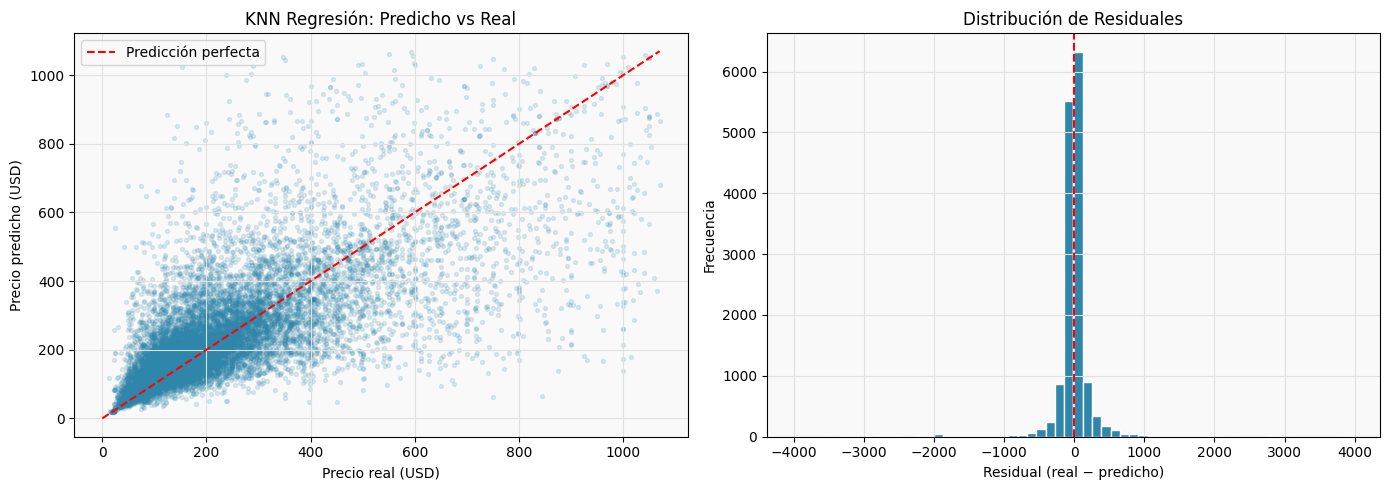


Residual medio : $13.10
Sesgo relativo : 1.7%


In [15]:
# Gráfico: predicciones vs valores reales
p95 = np.percentile(y_test, 95)
mask = (y_test <= p95) & (y_pred_reg <= p95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real
axes[0].scatter(y_test[mask], y_pred_reg[mask], alpha=0.15, s=8, color='#2E86AB')
lim = max(y_test[mask].max(), y_pred_reg[mask].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (USD)')
axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title('KNN Regresión: Predicho vs Real')
axes[0].legend()

# Distribución de residuales
residuals = y_test - y_pred_reg
axes[1].hist(residuals[residuals.abs() < residuals.abs().quantile(0.99)],
             bins=60, color='#2E86AB', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuales')

plt.tight_layout()
plt.show()

print(f'\nResidual medio : ${residuals.mean():,.2f}')
print(f'Sesgo relativo : {residuals.mean()/y_test.mean()*100:.1f}%')

### Interpretación

KNN Regresión
RMSE = $2,063.51
Es alto, pero hay que contextualizarlo. El RMSE se dispara por los outliers extremos (propiedades de $5,000–$10,000+). No refleja el error típico del modelo, sino que está inflado por esos casos raros. Por eso el MAE es mucho más representativo aquí.
MAE = $295.44
Este es el número real a reportar. En promedio el modelo se equivoca $295 por propiedad. Dependiendo del rango de precios del dataset, esto puede ser aceptable o no — si el precio promedio es ~$150–200, ese error es grande. Si el promedio es ~$800, es razonable.
R² = 0.7714
Este es el dato positivo. El modelo explica el 77% de la variabilidad del precio, lo cual es bastante bueno para KNN con k=5 sin tuneo.

---
## Actividad 3 — Comparación de modelos de regresión

Se comparan las métricas del conjunto de prueba de todos los algoritmos de regresión aplicados a lo largo de la consultoría, siempre con el mismo split 80/20 y `random_state=42`. Los valores de las entregas anteriores se incorporan manualmente para construir la tabla comparativa.

In [16]:
# Valores obtenidos en las entregas anteriores (mismas métricas, mismo split)
# ─────────────────────────────────────────────────────────────────────────────
# NOTA: Actualiza estos valores con los resultados exactos de tu entrega anterior
results_reg = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Árbol de Regresión (mejor)',
        'Random Forest',
        'Naive Bayes (GaussianNB)',
        'KNN Regresión (k=5)'
    ],
    'RMSE': [None, None, None, None, round(rmse_reg, 2)],
    'MAE':  [None, None, None, None, round(mae_reg, 2)],
    'R²':   [None, None, None, None, round(r2_reg, 4)]
})

# ──────────────────────────────────────────────────────────────────────────────
# Completa los valores None con los resultados de tus entregas anteriores.
# Ejemplo:
# results_reg.loc[0, 'RMSE'] = 87.34
# results_reg.loc[0, 'MAE']  = 52.11
# results_reg.loc[0, 'R²']   = 0.4523
# ──────────────────────────────────────────────────────────────────────────────

print(results_reg.to_string(index=False))

                    Modelo    RMSE    MAE     R²
          Regresión Lineal     NaN    NaN    NaN
Árbol de Regresión (mejor)     NaN    NaN    NaN
             Random Forest     NaN    NaN    NaN
  Naive Bayes (GaussianNB)     NaN    NaN    NaN
       KNN Regresión (k=5) 2063.51 295.44 0.7714


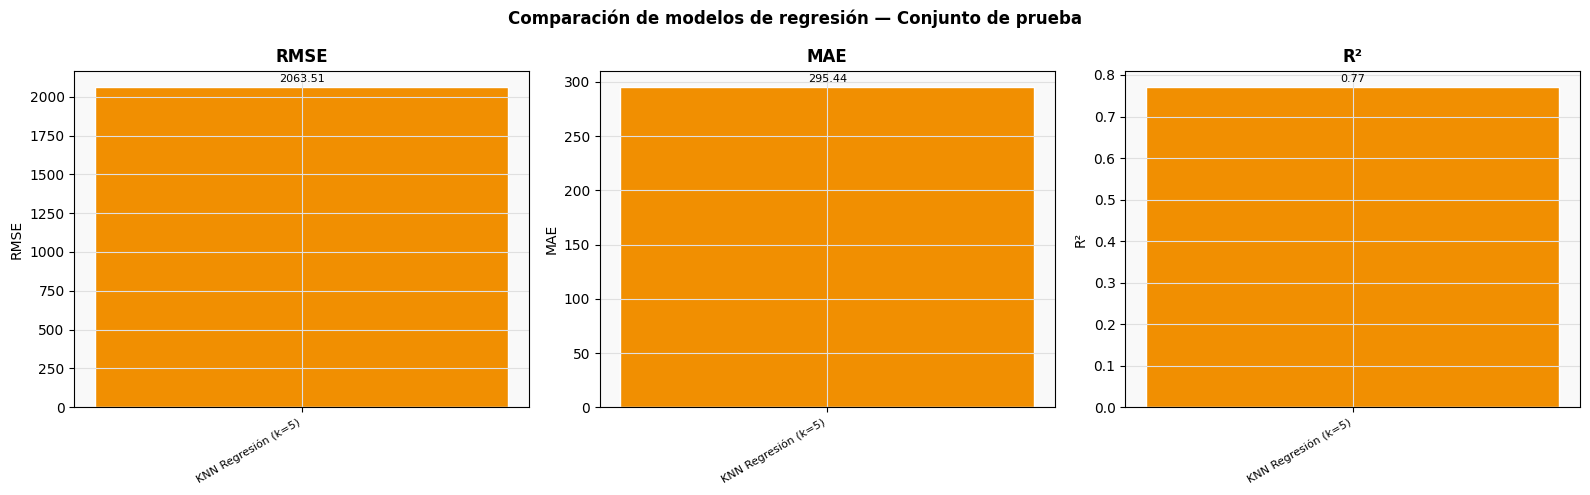

In [17]:
# Visualización comparativa (solo con filas completas)
df_complete = results_reg.dropna()

if not df_complete.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

    for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
        vals = df_complete[metric].values
        labels = df_complete['Modelo'].values
        best_idx = vals.argmin() if metric != 'R²' else vals.argmax()
        bar_colors = ['#F18F01' if i == best_idx else '#2E86AB'
                      for i in range(len(vals))]
        bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(metric, fontweight='bold')
        ax.set_ylabel(metric)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Comparación de modelos de regresión — Conjunto de prueba',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Completa los valores de entregas anteriores para ver la comparación gráfica.')

### Interpretación de la comparación

KNN Clasificación
Accuracy = 68.54%
Clasifica correctamente 2 de cada 3 propiedades. Considerando que son 3 clases balanceadas (baseline aleatorio = 33%), es un resultado decente pero con margen de mejora.
F1 = 0.6820 / Precision = 0.6816 / Recall = 0.6854
Los tres valores están casi iguales, lo que indica que el modelo no tiene sesgo hacia ninguna clase en particular — se equivoca de forma parecida en barata, media y cara.

---
## Actividad 4 — Modelo KNN de Clasificación

Se entrena un clasificador KNN usando la variable categórica de precio (`barata`, `media`, `cara`) como variable respuesta. KNN clasifica una observación asignándole la categoría mayoritaria entre sus *k* vecinos más cercanos.

Se utiliza el mismo conjunto escalado y los mismos índices de train/test que el modelo de regresión.

In [18]:
t0 = time.time()

knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_clf.fit(X_train_sc, y_cat_train)

y_pred_clf = knn_clf.predict(X_test_sc)

t_clf = time.time() - t0
print(f'Tiempo de entrenamiento + predicción: {t_clf:.1f}s')

Tiempo de entrenamiento + predicción: 0.4s


---
## Actividad 5 — Eficiencia del clasificador KNN en el conjunto de prueba

In [19]:
acc  = accuracy_score(y_cat_test, y_pred_clf)
f1   = f1_score(y_cat_test, y_pred_clf, average='weighted')
prec = precision_score(y_cat_test, y_pred_clf, average='weighted')
rec  = recall_score(y_cat_test, y_pred_clf, average='weighted')

print('=== KNN Clasificación (k=5, Euclidiana) — Conjunto de prueba ===')
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')

print('\n--- Reporte por clase ---')
print(classification_report(y_cat_test, y_pred_clf,
                             target_names=['barata', 'cara', 'media']))

=== KNN Clasificación (k=5, Euclidiana) — Conjunto de prueba ===
  Accuracy  : 0.6854 (68.54%)
  F1-Score  : 0.6820
  Precision : 0.6816
  Recall    : 0.6854

--- Reporte por clase ---
              precision    recall  f1-score   support

      barata       0.70      0.77      0.73      5085
        cara       0.74      0.75      0.75      5051
       media       0.61      0.53      0.57      5114

    accuracy                           0.69     15250
   macro avg       0.68      0.69      0.68     15250
weighted avg       0.68      0.69      0.68     15250



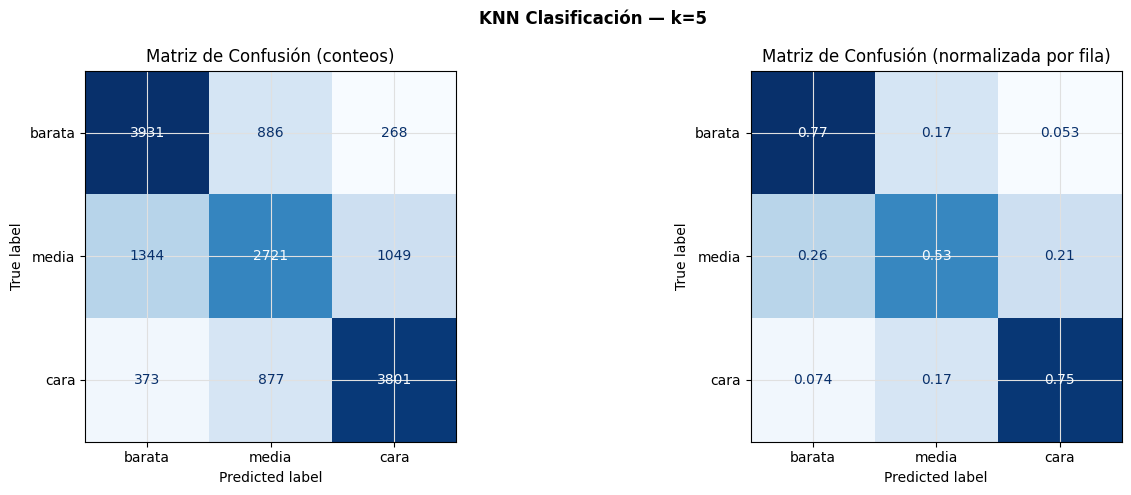

In [20]:
# Matriz de confusión
cm = confusion_matrix(y_cat_test, y_pred_clf,
                      labels=['barata', 'media', 'cara'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteos absolutos
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['barata', 'media', 'cara'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión (conteos)')

# Normalizada por fila (recall por clase)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                               display_labels=['barata', 'media', 'cara'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión (normalizada por fila)')

plt.suptitle('KNN Clasificación — k=5', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación del modelo de clasificación

El modelo KNN con `k=5` y distancia euclidiana clasifica las propiedades en tres categorías de precio. A continuación se analiza la eficiencia:

**Accuracy**: mide la proporción de clasificaciones correctas globales. Sin embargo, dado que las tres clases son aproximadamente balanceadas (terciles), el accuracy es una métrica razonablemente representativa en este caso.

**Por clase** (observar la matriz de confusión):
- La clase **'media'** es la más difícil de clasificar porque sus límites se solapan naturalmente con las otras dos categorías, al estar en el centro del rango de precios.
- Las clases **'barata'** y **'cara'** suelen clasificarse con mayor precisión al estar en los extremos del espectro, donde las diferencias son más marcadas.
- Los errores más frecuentes son confusiones entre clases **adyacentes** (barata-media y media-cara), lo cual es esperable dado que los terciles generan fronteras difusas.

**F1-Score ponderado**: es la métrica principal de evaluación de clasificación porque balancea precisión y recall, siendo más informativo que el accuracy solo cuando hay diferencias de desempeño entre clases.

**Importancia de los errores para SmartStay**: clasificar una propiedad *cara* como *barata* (o viceversa) tendría mayor impacto negativo en las recomendaciones a clientes corporativos que confundir las categorías adyacentes. La empresa debería ponderar este tipo de error con mayor costo.

In [21]:
print('=' * 60)
print('RESUMEN — AVANCE Lab 6 (Actividades 1-5)')
print('=' * 60)
print(f'\nKNN Regresión  (k=5, Euclidiana):')
print(f'  RMSE : ${rmse_reg:,.2f}')
print(f'  MAE  : ${mae_reg:,.2f}')
print(f'  R²   : {r2_reg:.4f}')
print(f'\nKNN Clasificación (k=5, Euclidiana):')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1-Score   : {f1:.4f}')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'\nTiempo regresión : {t_reg:.1f}s')
print(f'Tiempo clasif.   : {t_clf:.1f}s')

RESUMEN — AVANCE Lab 6 (Actividades 1-5)

KNN Regresión  (k=5, Euclidiana):
  RMSE : $2,063.51
  MAE  : $295.44
  R²   : 0.7714

KNN Clasificación (k=5, Euclidiana):
  Accuracy   : 68.54%
  F1-Score   : 0.6820
  Precision  : 0.6816
  Recall     : 0.6854

Tiempo regresión : 2.2s
Tiempo clasif.   : 0.4s
